In [37]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [38]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print("Using GPU")

In [39]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [40]:
df = pd.read_csv("../data/processed/master_training_data.csv" , low_memory=False)
df.head()

,timestamp,demand_mw,date,hour,day_of_week,day_of_month,month,weekend,season,temperature_2m,...,cal_is_bank_holiday_england_wales,cal_is_bank_holiday_scotland,cal_is_bank_holiday,cal_event_count,cal_event_names,cal_is_covid_lockdown,cal_is_general_election,cal_is_major_football,cal_is_event_day,cal_is_non_working_day
0,2010-01-01 00:00:00,36566.5,2010-01-01,0,4,1,1,0,winter,-0.76,...,0,0,1,0,NaN,0,0,0,0,1
1,2010-01-01 01:00:00,35852.5,2010-01-01,1,4,1,1,0,winter,-1.02,...,0,0,1,0,NaN,0,0,0,0,1
2,2010-01-01 02:00:00,34189.5,2010-01-01,2,4,1,1,0,winter,-1.17,...,0,0,1,0,NaN,0,0,0,0,1
3,2010-01-01 03:00:00,32453.0,2010-01-01,3,4,1,1,0,winter,-1.21,...,0,0,1,0,NaN,0,0,0,0,1
4,2010-01-01 04:00:00,30450.5,2010-01-01,4,4,1,1,0,winter,-1.21,...,0,0,1,0,NaN,0,0,0,0,1


In [41]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = (
    df
    .sort_values("timestamp")
    .reset_index(drop=True)
)

In [42]:
print("Shape:", df.shape)

print(
    df[["timestamp", "demand_mw"]].head()
)

print(
    df[["timestamp", "demand_mw"]].tail()
)

Shape: (145784, 51)
            timestamp  demand_mw
0 2010-01-01 00:00:00    36566.5
1 2010-01-01 01:00:00    35852.5
2 2010-01-01 02:00:00    34189.5
3 2010-01-01 03:00:00    32453.0
4 2010-01-01 04:00:00    30450.5
                 timestamp  demand_mw
145779 2026-08-19 03:00:00    20840.5
145780 2026-08-19 04:00:00    20039.5
145781 2026-08-19 05:00:00    19892.0
145782 2026-08-19 06:00:00    21752.0
145783 2026-08-19 07:00:00    24412.5


In [43]:
data = df[
    ["timestamp", "demand_mw"]
].copy()

print(data.isna().sum())

timestamp    0
demand_mw    0
dtype: int64


In [44]:
time_diff = data["timestamp"].diff()

hourly_ok = (
    time_diff.iloc[1:]
    == pd.Timedelta(hours=1)
)

print(
    "Hourly intervals:",
    hourly_ok.sum()
)

print(
    "Total intervals:",
    len(data) - 1
)

print(
    "All hourly:",
    hourly_ok.all()
)

Hourly intervals: 145783
Total intervals: 145783
All hourly: True


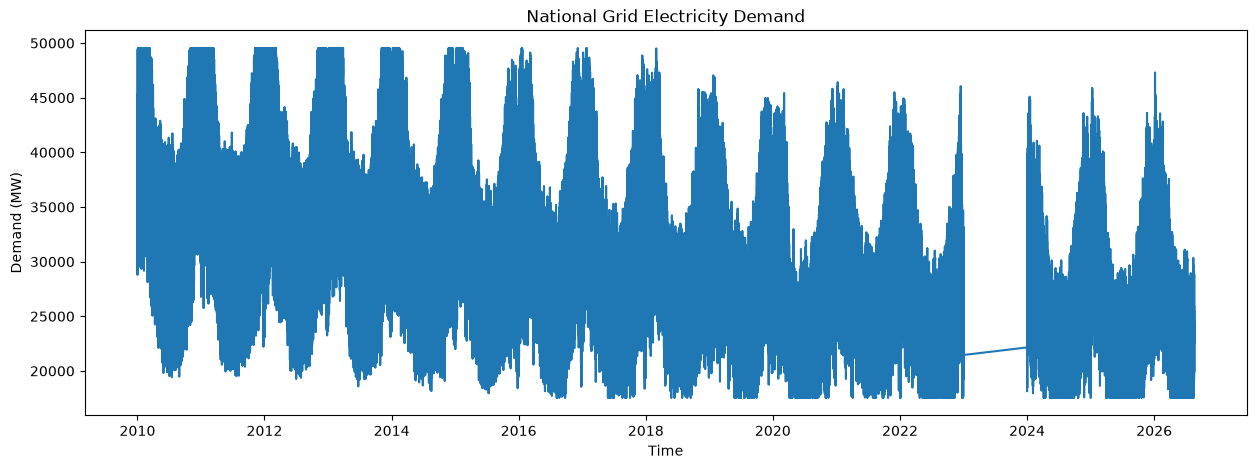

In [47]:
plt.figure(figsize=(15, 5))

plt.plot(
    data["timestamp"],
    data["demand_mw"]
)

plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.title("National Grid Electricity Demand")

plt.show()

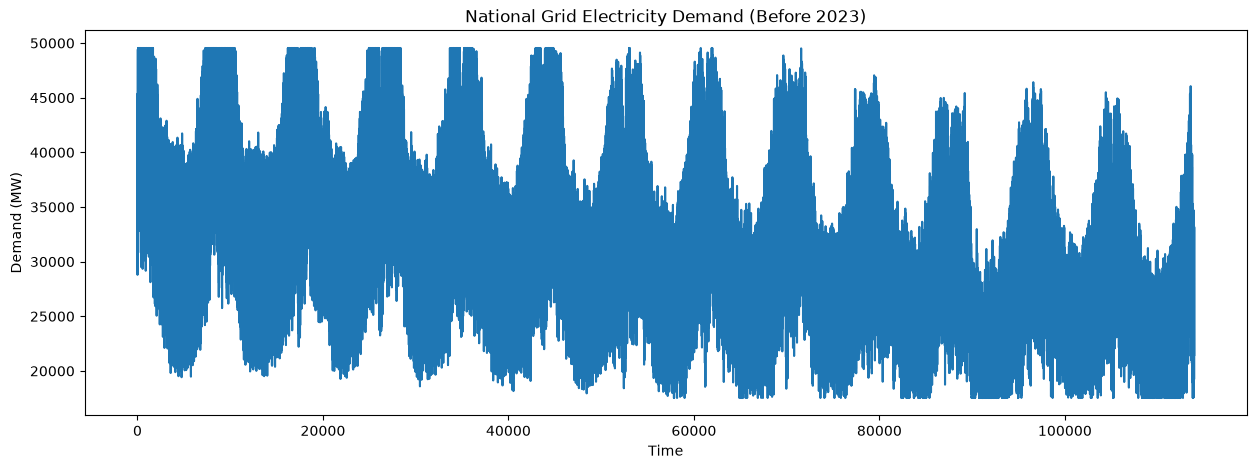

In [50]:
data.loc[data["timestamp"] < "2023-01-01", "demand_mw"].plot(
    figsize=(15, 5),
    title="National Grid Electricity Demand (Before 2023)"
)
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.show()

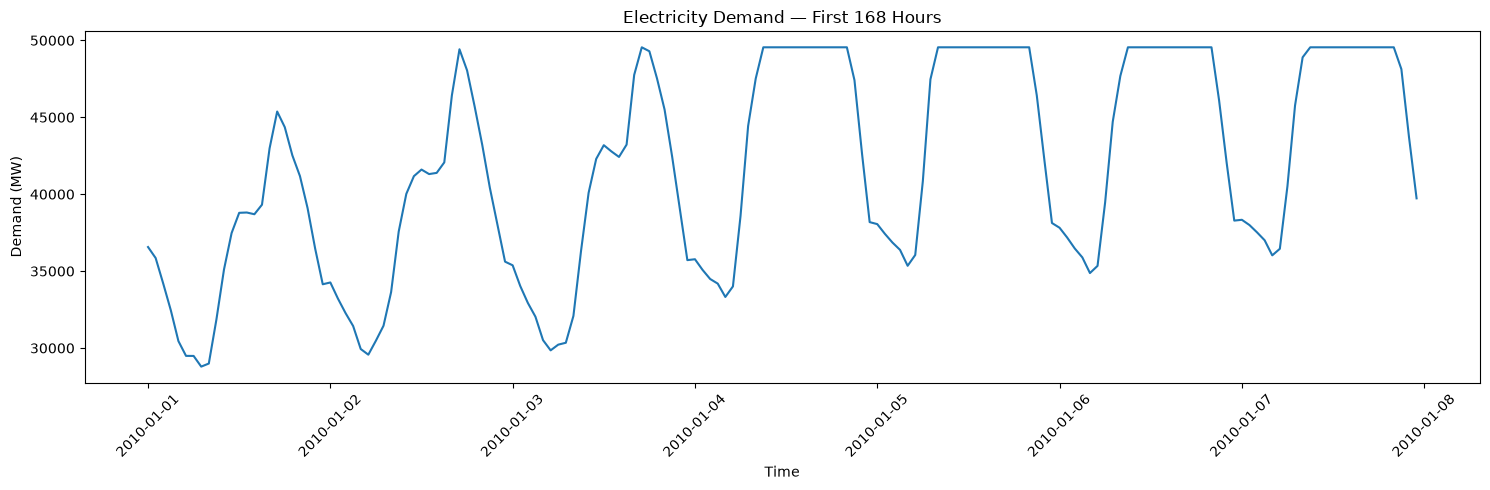

In [51]:
one_week = data.iloc[:168]

plt.figure(figsize=(15, 5))

plt.plot(
    one_week["timestamp"],
    one_week["demand_mw"]
)

plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.title("Electricity Demand — First 168 Hours")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

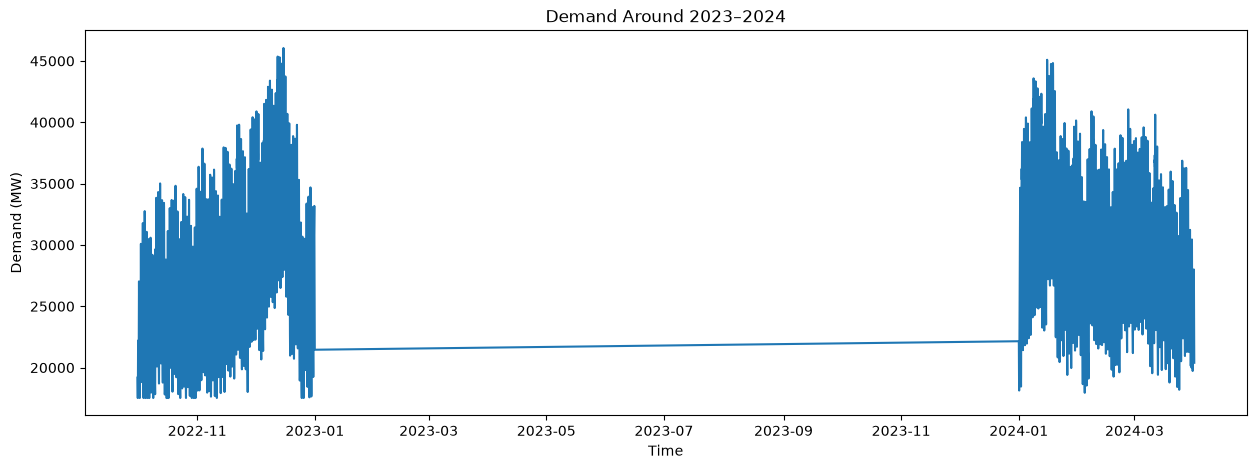

In [52]:
problem_period = data[
    (data["timestamp"] >= "2022-10-01") &
    (data["timestamp"] <= "2024-04-01")
]

plt.figure(figsize=(15, 5))

plt.plot(
    problem_period["timestamp"],
    problem_period["demand_mw"]
)

plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.title("Demand Around 2023–2024")

plt.show()

In [53]:
problem_period[
    ["timestamp", "demand_mw"]
].head(20)

,timestamp,demand_mw
111744,2022-10-01 00:00:00,19186.5
111745,2022-10-01 01:00:00,18462.0
111746,2022-10-01 02:00:00,17872.0
111747,2022-10-01 03:00:00,17525.0
111748,2022-10-01 04:00:00,17525.0
111749,2022-10-01 05:00:00,17525.0
111750,2022-10-01 06:00:00,18647.5
111751,2022-10-01 07:00:00,20619.5
111752,2022-10-01 08:00:00,22208.5
111753,2022-10-01 09:00:00,21790.5


In [54]:
n = len(data)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

print("Total observations:", n)

print("Train end:", train_end)
print("Validation end:", val_end)

Total observations: 145784
Train end: 116627
Validation end: 131205


In [55]:
print(
    "Train:",
    data.iloc[0]["timestamp"],
    "→",
    data.iloc[train_end - 1]["timestamp"]
)

print(
    "Validation:",
    data.iloc[train_end]["timestamp"],
    "→",
    data.iloc[val_end - 1]["timestamp"]
)

print(
    "Test:",
    data.iloc[val_end]["timestamp"],
    "→",
    data.iloc[-1]["timestamp"]
)

Train: 2010-01-01 00:00:00 → 2023-04-22 10:00:00
Validation: 2023-04-22 11:00:00 → 2024-12-19 20:00:00
Test: 2024-12-19 21:00:00 → 2026-08-19 07:00:00


In [56]:
scaler = StandardScaler()

In [57]:
train_values = data.iloc[
    :train_end
][["demand_mw"]].values

scaler.fit(train_values)

StandardScaler()

In [58]:
scaled_demand = scaler.transform(
    data[["demand_mw"]].values
).astype(np.float32)

In [59]:
print(scaled_demand.shape)

print(
    "Scaled mean approximately:",
    scaled_demand[:train_end].mean()
)

print(
    "Scaled std approximately:",
    scaled_demand[:train_end].std()
)

(145784, 1)
Scaled mean approximately: 0.0
Scaled std approximately: 1.0


In [60]:
def create_windows(
    values,
    input_length,
    forecast_horizon,
    train_end,
    val_end
):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []

    n = len(values)

    for start in range(
        n - input_length - forecast_horizon + 1
    ):

        input_start = start
        input_end = start + input_length

        target_start = input_end
        target_end = (
            target_start + forecast_horizon
        )

        X = values[
            input_start:input_end
        ]

        y = values[
            target_start:target_end,
            0
        ]

        # Training sample
        if target_end <= train_end:

            X_train.append(X)
            y_train.append(y)

        # Validation sample
        elif (
            target_start >= train_end
            and target_end <= val_end
        ):

            X_val.append(X)
            y_val.append(y)

        # Test sample
        elif target_start >= val_end:

            X_test.append(X)
            y_test.append(y)

    return (
        np.array(X_train, dtype=np.float32),
        np.array(y_train, dtype=np.float32),
        np.array(X_val, dtype=np.float32),
        np.array(y_val, dtype=np.float32),
        np.array(X_test, dtype=np.float32),
        np.array(y_test, dtype=np.float32)
    )

In [62]:
INPUT_LENGTH = 168
FORECAST_HORIZON = 24

In [63]:
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
) = create_windows(
    scaled_demand,
    INPUT_LENGTH,
    FORECAST_HORIZON,
    train_end,
    val_end
)

In [64]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (116436, 168, 1)
y_train: (116436, 24)
X_val: (14555, 168, 1)
y_val: (14555, 24)
X_test: (14556, 168, 1)
y_test: (14556, 24)


In [65]:
print("One X sample:", X_train[0].shape)
print("One y sample:", y_train[0].shape)

One X sample: (168, 1)
One y sample: (24,)


In [66]:
class LoadForecastDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )

In [67]:
train_dataset = LoadForecastDataset(
    X_train,
    y_train
)

val_dataset = LoadForecastDataset(
    X_val,
    y_val
)

test_dataset = LoadForecastDataset(
    X_test,
    y_test
)

In [68]:
BATCH_SIZE = 64

In [69]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [70]:
X_batch, y_batch = next(
    iter(train_loader)
)

print("X batch:", X_batch.shape)
print("y batch:", y_batch.shape)

X batch: torch.Size([64, 168, 1])
y batch: torch.Size([64, 24])


In [71]:
class BaselineLSTM(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        dense_size=32,
        forecast_horizon=24,
        dropout=0.2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.fc1 = nn.Linear(
            hidden_size,
            dense_size
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            dense_size,
            forecast_horizon
        )

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        last_output = lstm_out[:, -1, :]

        x = self.dropout(
            last_output
        )

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        return x

In [72]:
model = BaselineLSTM(
    input_size=1,
    hidden_size=64,
    dense_size=32,
    forecast_horizon=24,
    dropout=0.2
).to(device)

In [73]:
X_batch, y_batch = next(
    iter(train_loader)
)

X_batch = X_batch.to(device)

with torch.no_grad():

    output = model(X_batch)

print(
    "Input shape:",
    X_batch.shape
)

print(
    "Model output shape:",
    output.shape
)

print(
    "Target shape:",
    y_batch.shape
)

Input shape: torch.Size([64, 168, 1])
Model output shape: torch.Size([64, 24])
Target shape: torch.Size([64, 24])


In [74]:
criterion = nn.MSELoss()

In [75]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [76]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(
            X_batch
        )

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * X_batch.size(0)
        )

    return (
        total_loss
        / len(loader.dataset)
    )

In [77]:
def evaluate_loss(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(
                X_batch
            )

            loss = criterion(
                predictions,
                y_batch
            )

            total_loss += (
                loss.item()
                * X_batch.size(0)
            )

    return (
        total_loss
        / len(loader.dataset)
    )

In [ ]:
EPOCHS = 100
PATIENCE = 20

In [79]:
best_val_loss = float("inf")

best_model_state = None

patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = evaluate_loss(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value
            in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

    if patience_counter >= PATIENCE:

        print(
            "Early stopping triggered."
        )

        break

Epoch 001 | Train Loss: 0.325562 | Val Loss: 0.140643
Epoch 002 | Train Loss: 0.137426 | Val Loss: 0.219408
Epoch 003 | Train Loss: 0.120879 | Val Loss: 0.177959
Epoch 004 | Train Loss: 0.112129 | Val Loss: 0.084169
Epoch 005 | Train Loss: 0.109786 | Val Loss: 0.075621
Epoch 006 | Train Loss: 0.103903 | Val Loss: 0.092059
Epoch 007 | Train Loss: 0.102979 | Val Loss: 0.066356
Epoch 008 | Train Loss: 0.098639 | Val Loss: 0.072234
Epoch 009 | Train Loss: 0.097355 | Val Loss: 0.103856
Epoch 010 | Train Loss: 0.095317 | Val Loss: 0.100809
Epoch 011 | Train Loss: 0.093699 | Val Loss: 0.128141
Epoch 012 | Train Loss: 0.091664 | Val Loss: 0.126490
Epoch 013 | Train Loss: 0.088826 | Val Loss: 0.109291
Epoch 014 | Train Loss: 0.085906 | Val Loss: 0.090013
Epoch 015 | Train Loss: 0.082446 | Val Loss: 0.066921
Epoch 016 | Train Loss: 0.079452 | Val Loss: 0.061763
Epoch 017 | Train Loss: 0.076578 | Val Loss: 0.061450
Epoch 018 | Train Loss: 0.086830 | Val Loss: 0.049169
Epoch 019 | Train Loss: 0.07

In [80]:
model.load_state_dict(
    best_model_state
)

model = model.to(device)

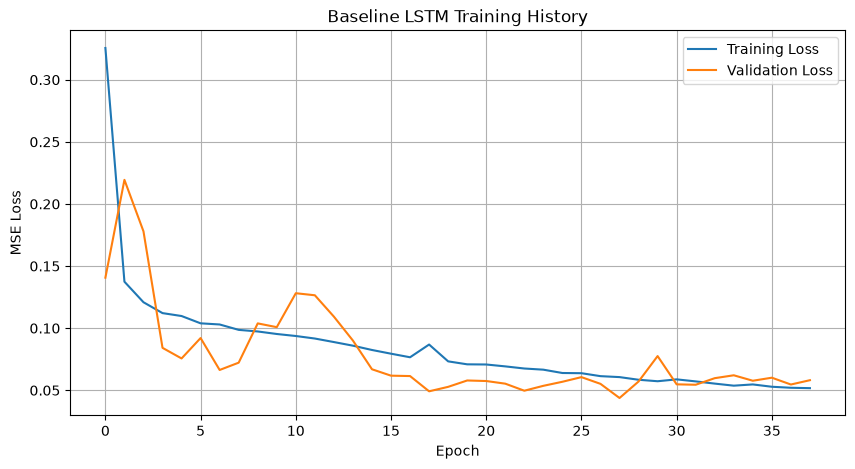

In [81]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title(
    "Baseline LSTM Training History"
)

plt.legend()
plt.grid(True)

plt.show()

In [82]:
def predict(
    model,
    loader,
    device
):

    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)

            output = model(
                X_batch
            )

            predictions.append(
                output.cpu().numpy()
            )

            actuals.append(
                y_batch.numpy()
            )

    predictions = np.vstack(
        predictions
    )

    actuals = np.vstack(
        actuals
    )

    return predictions, actuals

In [83]:
pred_scaled, actual_scaled = predict(
    model,
    test_loader,
    device
)

print(pred_scaled.shape)
print(actual_scaled.shape)

(14556, 24)
(14556, 24)


In [84]:
pred_mw = scaler.inverse_transform(
    pred_scaled.reshape(-1, 1)
).reshape(
    pred_scaled.shape
)

actual_mw = scaler.inverse_transform(
    actual_scaled.reshape(-1, 1)
).reshape(
    actual_scaled.shape
)

In [85]:
mae = mean_absolute_error(
    actual_mw.flatten(),
    pred_mw.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actual_mw.flatten(),
        pred_mw.flatten()
    )
)

r2 = r2_score(
    actual_mw.flatten(),
    pred_mw.flatten()
)

print(
    f"MAE  : {mae:.2f} MW"
)

print(
    f"RMSE : {rmse:.2f} MW"
)

print(
    f"R²   : {r2:.4f}"
)

MAE  : 1846.01 MW
RMSE : 2402.05 MW
R²   : 0.8423


In [86]:
daily_naive_scaled = X_test[
    :, -24:, 0
]

In [87]:
daily_naive_mw = scaler.inverse_transform(
    daily_naive_scaled.reshape(-1, 1)
).reshape(
    daily_naive_scaled.shape
)

In [88]:
daily_mae = mean_absolute_error(
    actual_mw.flatten(),
    daily_naive_mw.flatten()
)

daily_rmse = np.sqrt(
    mean_squared_error(
        actual_mw.flatten(),
        daily_naive_mw.flatten()
    )
)

print(
    f"Daily Naive MAE  : {daily_mae:.2f} MW"
)

print(
    f"Daily Naive RMSE : {daily_rmse:.2f} MW"
)

Daily Naive MAE  : 1842.46 MW
Daily Naive RMSE : 2578.33 MW


In [89]:
weekly_naive_scaled = X_test[
    :, :24, 0
]

In [90]:
weekly_naive_mw = scaler.inverse_transform(
    weekly_naive_scaled.reshape(-1, 1)
).reshape(
    weekly_naive_scaled.shape
)


In [91]:
weekly_mae = mean_absolute_error(
    actual_mw.flatten(),
    weekly_naive_mw.flatten()
)

weekly_rmse = np.sqrt(
    mean_squared_error(
        actual_mw.flatten(),
        weekly_naive_mw.flatten()
    )
)

print(
    f"Weekly Naive MAE  : {weekly_mae:.2f} MW"
)

print(
    f"Weekly Naive RMSE : {weekly_rmse:.2f} MW"
)

Weekly Naive MAE  : 2113.64 MW
Weekly Naive RMSE : 2890.45 MW


In [92]:
results = pd.DataFrame({
    "Model": [
        "Daily Seasonal Naive",
        "Weekly Seasonal Naive",
        "Baseline LSTM"
    ],

    "MAE_MW": [
        daily_mae,
        weekly_mae,
        mae
    ],

    "RMSE_MW": [
        daily_rmse,
        weekly_rmse,
        rmse
    ]
})

results

,Model,MAE_MW,RMSE_MW
0,Daily Seasonal Naive,1842.464355,2578.331534
1,Weekly Seasonal Naive,2113.644531,2890.453425
2,Baseline LSTM,1846.008667,2402.046211


In [93]:
sample = 0

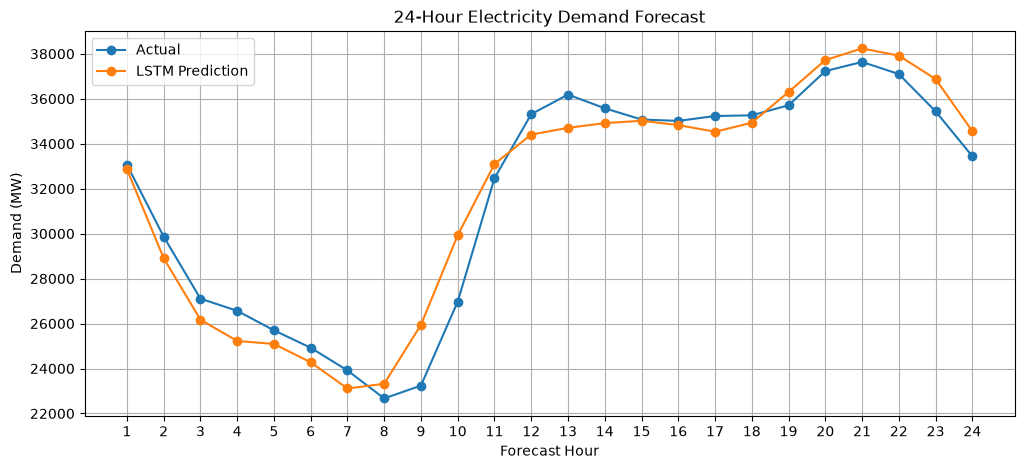

In [94]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(1, 25),
    actual_mw[sample],
    marker="o",
    label="Actual"
)

plt.plot(
    range(1, 25),
    pred_mw[sample],
    marker="o",
    label="LSTM Prediction"
)

plt.xlabel("Forecast Hour")
plt.ylabel("Demand (MW)")

plt.title(
    "24-Hour Electricity Demand Forecast"
)

plt.xticks(
    range(1, 25)
)

plt.legend()
plt.grid(True)

plt.show()